In [96]:
!pip install --upgrade scipy

In [97]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy.stats import anderson, MonteCarloMethod

In [98]:
dados = pd.read_spss("alunos.sav")
dados

,raclog,int_tex,ingles,redacao,grupo,Socio
0,7.692308,7.00,8.666667,8.0,CDF,A
1,9.615385,7.25,9.000000,8.0,CDF,A
2,9.615385,6.25,8.666667,8.5,CDF,A
3,9.615385,7.00,7.333333,9.0,CDF,A
4,9.230769,7.25,7.000000,8.5,CDF,A
...,...,...,...,...,...,...
115,5.384615,3.75,5.666667,6.0,Fundão,C
116,6.538462,5.25,5.666667,4.0,Fundão,C
117,5.384615,5.00,4.333333,6.0,Fundão,C
118,3.846154,5.50,5.333333,6.0,Fundão,C


In [99]:
def testes_normalidade(dados):
    media = np.mean(dados)
    dp = np.std(dados, ddof=1) # Calcula o desvio-padrão para n - 1

    testes = ["Shapiro-Wilk", "Kolmogorov-Smirnov", "Anderson-Darling"]
    estatisticas = []
    p_valores = []

    sw_stat, sw_p = stats.shapiro(dados)
    estatisticas.append(sw_stat)
    p_valores.append(sw_p)

    ks_stat, ks_p = stats.kstest(dados, cdf="norm", args=(media, dp), N=len(dados))
    estatisticas.append(ks_stat)
    p_valores.append(ks_p)

    mc_method = MonteCarloMethod(n_resamples=9999)
    ad_stat, ad_p = stats.anderson(dados, dist="norm", method=mc_method)
    estatisticas.append(ad_stat)
    p_valores.append(ad_p)

    return pd.DataFrame({"Prova": dados.name, "Teste de Normalidade": testes, "Estatística": estatisticas, "p": p_valores})


In [100]:
rac_log = testes_normalidade(dados["raclog"])

In [101]:
int_tex = testes_normalidade(dados["int_tex"])

In [102]:
ingles = testes_normalidade(dados["ingles"])

In [103]:
redacao = testes_normalidade(dados["redacao"])

In [104]:
pd.concat([rac_log, int_tex, ingles, redacao], ignore_index=True)

,Prova,Teste de Normalidade,Estatística,p
0,raclog,Shapiro-Wilk,0.977020,0.037703
1,raclog,Kolmogorov-Smirnov,0.085363,0.327397
2,raclog,Anderson-Darling,0.716655,0.057200
3,int_tex,Shapiro-Wilk,0.985430,0.224520
4,int_tex,Kolmogorov-Smirnov,0.065795,0.651882
5,int_tex,Anderson-Darling,0.478821,0.236700
6,ingles,Shapiro-Wilk,0.966734,0.004571
7,ingles,Kolmogorov-Smirnov,0.093814,0.226867
8,ingles,Anderson-Darling,1.069274,0.007400
9,redacao,Shapiro-Wilk,0.930388,0.000010


In [121]:
colunas = ["raclog", "int_tex", "ingles", "redacao"]


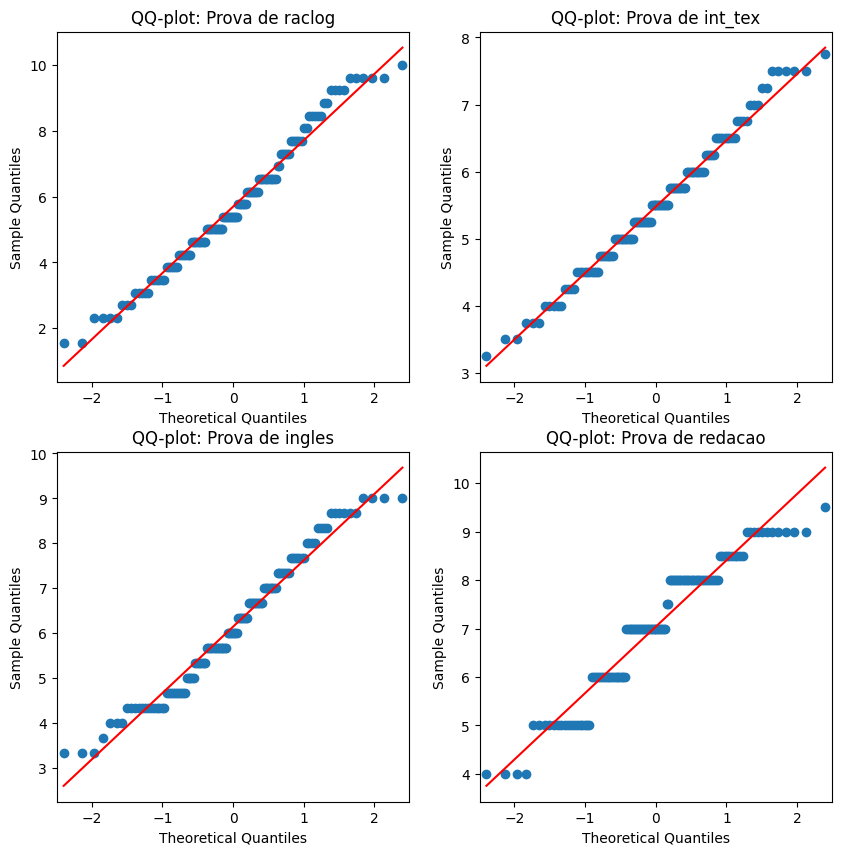

In [127]:


fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for i, ax in enumerate(axes.flatten()):
    # stats.probplot(dados[colunas[i]], dist="norm", plot=plt)
    sm.qqplot(dados[colunas[i]], line='s', ax=ax)
    ax.set_title(f"QQ-plot: Prova de {colunas[i]}")
plt.show()